In [1]:
from pathlib import Path
import pandas as pd
import timm
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import random

In [2]:
device = "cpu"

model = timm.create_model("tf_efficientnetv2_m.in21k_ft_in1k", pretrained=False, num_classes=2)
model.load_state_dict(torch.load("/Users/jjburrell/Downloads/efficientnetv2_m_best.pt", map_location=device, weights_only=True))
model.to(device).eval()

EfficientNet(
  (conv_stem): Conv2dSame(3, 24, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): ConvBnAct(
        (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (drop_path): Identity()
      )
      (1): ConvBnAct(
        (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (drop_path):

In [3]:
CLASSES = ["Cat", "Dog"]
IMG_SIZE = 224
OUT_CSV = Path("predictions.csv")
EXPECTED_COLUMNS = ["filename", "pred_label", "p_cat", "p_dog"]
IMAGE_DIR_CANDIDATES = [Path("Challenge_Images"), Path("challenge_images")]

def resolve_image_dir() -> Path | None:
    for candidate in IMAGE_DIR_CANDIDATES:
        if candidate.exists() and candidate.is_dir():
            return candidate
    return None

device = "cpu"

model = timm.create_model("tf_efficientnetv2_m.in21k_ft_in1k", pretrained=False, num_classes=2)
model.load_state_dict(torch.load("/Users/jjburrell/Downloads/efficientnetv2_m_best.pt", map_location=device, weights_only=True))
model.to(device).eval()

preprocess = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

EXTS = {".jpg", ".jpeg", ".png"}
IMAGE_DIR = resolve_image_dir()
paths = sorted(p for p in IMAGE_DIR.rglob("*") if p.suffix.lower() in EXTS) if IMAGE_DIR else []

def classify(path: Path) -> dict:
    img = Image.open(path).convert("RGB")
    x = preprocess(img).unsqueeze(0).to(device) 
    with torch.inference_mode():
        p_cat, p_dog = F.softmax(model(x), dim=1) [0].tolist()
        return{
            "filename": path.name,
            "pred_label": CLASSES[0 if p_cat > p_dog else 1],
            "p_cat": p_cat,
            "p_dog": p_dog,
        }
    
if not paths:
    searched = ", ".join(str(path) for path in IMAGE_DIR_CANDIDATES)
    print(f"No challenge images found. Looked in: {searched}")

df = pd.DataFrame((classify(p) for p in tqdm(paths, desc="classifying")), columns=EXPECTED_COLUMNS)
df.to_csv(OUT_CSV, index=False)
print(df["pred_label"].value_counts())
df.head()



classifying: 0it [00:00, ?it/s]

KeyError: 'pred_label'

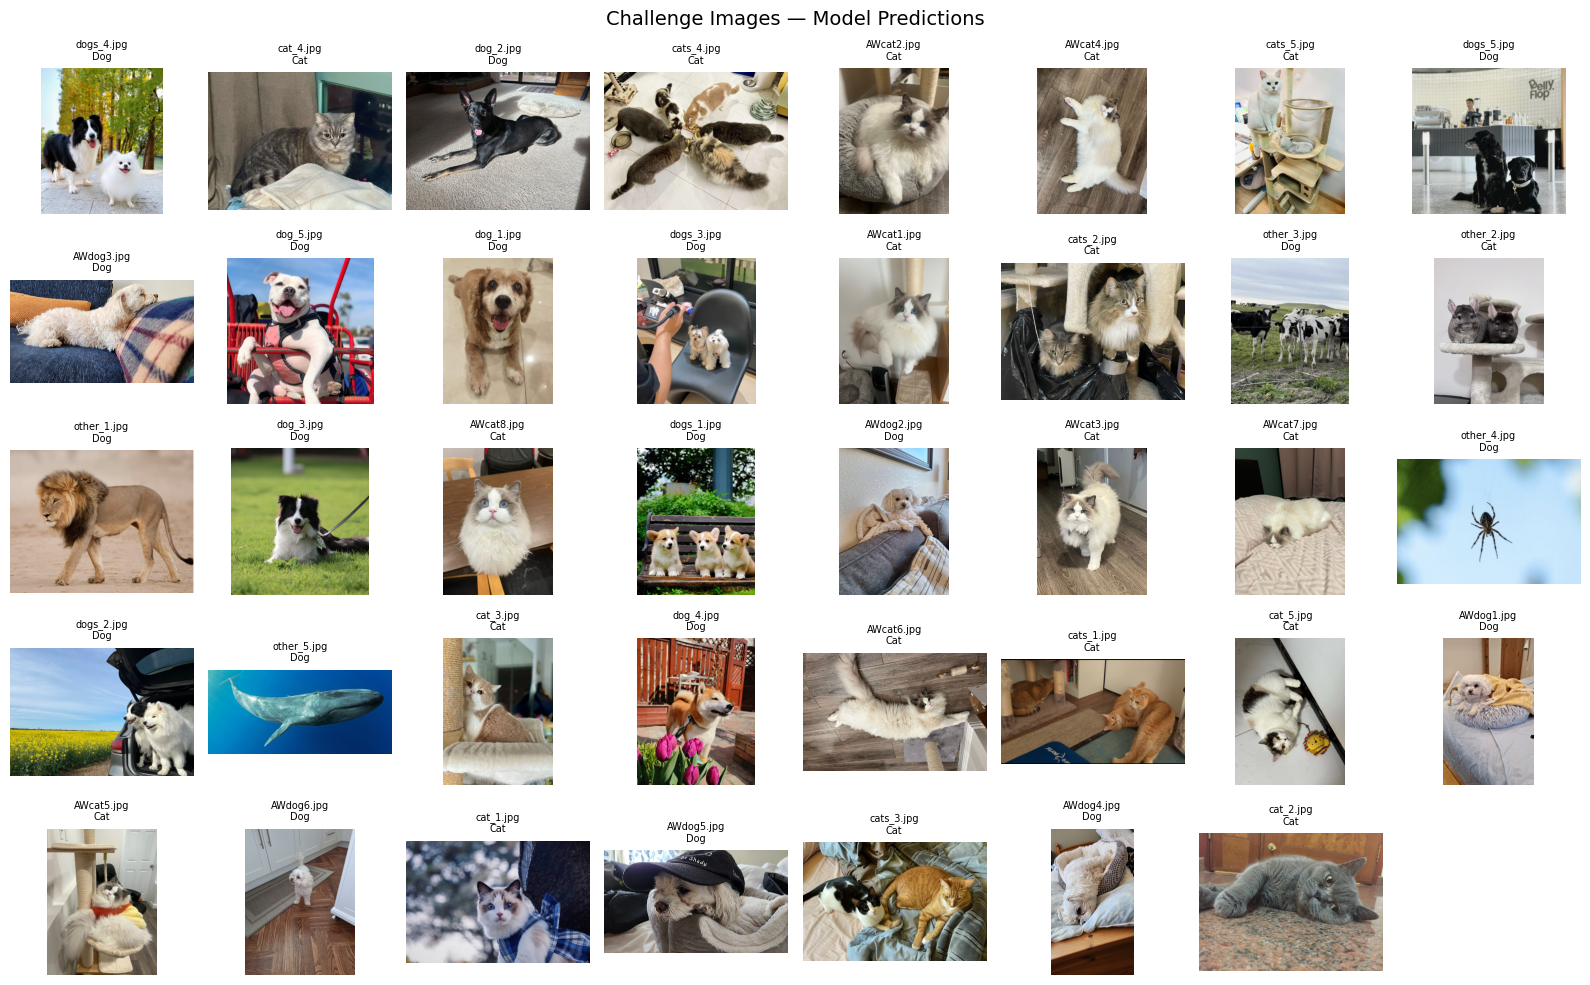

In [ ]:
df = pd.read_csv("predictions.csv")
if df.empty:
    print("predictions.csv is empty. Put images in Challenge_Images/ or challenge_images/ and rerun the classifier cell.")
else:
    image_dir = resolve_image_dir()
    samples = df.sample(min(40, len(df)))

    fig, axes = plt.subplots(5, 8, figsize=(16, 10))
    for i, ax in enumerate(axes.flat):
        if i < len(samples):
            row = samples.iloc[i]
            ax.imshow(Image.open(image_dir / row["filename"]))
            ax.set_title(f"{row['filename']}\n{row['pred_label']}", fontsize=7)
        ax.axis("off")
    fig.suptitle("Challenge Images - Model Predictions", fontsize=14)
    fig.tight_layout()
    plt.show()


In [4]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

df = pd.read_csv("predictions.csv")
df = df[df["filename"].str.contains("cat|dog", case=False)]
y_true = df["filename"].str.contains("cat", case=False).astype(int)
y_score = df["p_cat"]
n = len(df)

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

prec, rec, _ = precision_recall_curve(y_true, y_score)
prc_auc = auc(rec, prec)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
ax1.plot([0, 1], [0, 1], "k--", lw=1)
ax1.set(xlabel="FPR", ylabel="TPR", title="ROC — Cat vs Dog")
ax1.legend()

ax2.plot(rec, prec, lw=2, label=f"AUC = {prc_auc:.4f}")
ax2.set(xlabel="Recall", ylabel="Precision", title="PRC — Cat (positive class)")
ax2.legend()

fig.suptitle("Challenge Set Evaluation (small sample, see training in my hotdognothotdog.ipynb for full val‑set curves)",
             fontsize=10, style="italic", y=0.02)
fig.tight_layout()
plt.show()

EmptyDataError: No columns to parse from file